# Modelos de Aprendizaje No Supervisado — Salud Mental en Adolescentes
## Semana 3 · Lab 2
## Grupo 2



**Dataset:** Teen Mental Health Dataset ([Kaggle](https://www.kaggle.com/datasets/algozee/teenager-menthal-healy))  
**Descripción:** Estudio del impacto del uso de redes sociales en la salud mental de adolescentes (13-19 años).  
**Objetivo:** Segmentar perfiles de adolescentes mediante K-Means, DBSCAN, PCA y t-SNE para identificar grupos en riesgo y comprender patrones de comportamiento digital.


## Parte 1: Preparación del entorno

A continuación se importan todas las librerías necesarias para el análisis no supervisado.  
El dataset no requiere instalaciones adicionales; todas las librerías pertenecen al ecosistema estándar de ciencia de datos en Python.


In [35]:
# Parte 1: Preparación del entorno

!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print(' Librerías cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')


 Librerías cargadas correctamente
   pandas  2.2.2
   numpy   2.0.2
   sklearn 1.6.1


## Parte 2: Carga y Análisis Exploratorio de los Datos (EDA)

### Descripción del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica | Edad del adolescente (13-19) |
| `gender` | Categórica | Género (male / female) |
| `daily_social_media_hours` | Numérica | Horas diarias en redes sociales |
| `platform_usage` | Categórica | Plataforma principal (Instagram / TikTok / Both) |
| `sleep_hours` | Numérica | Horas de sueño por noche |
| `screen_time_before_sleep` | Numérica | Horas de pantalla antes de dormir |
| `academic_performance` | Numérica | Rendimiento académico (escala) |
| `physical_activity` | Numérica | Nivel de actividad física |
| `social_interaction_level` | Categórica | Nivel de interacción social (low / medium / high) |
| `stress_level` | Numérica | Nivel de estrés (1-10) |
| `anxiety_level` | Numérica | Nivel de ansiedad (1-10) |
| `addiction_level` | Numérica | Nivel de adicción a redes (1-10) |
| `depression_label` | Binaria | Etiqueta de depresión (0 = no, 1 = sí) |

> **Nota sobre la variable `depression_label`:** En un modelo no supervisado **no la usamos como etiqueta** durante el entrenamiento. La conservamos solo para comparación posterior y validación externa de los clusters.


In [36]:
# Parte 2: Carga y análisis exploratorio del dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print('=== Primeras filas ===')
print(df.head())
print()
print('=== Información general ===')
print(df.info())
print()
print('=== Estadísticas descriptivas ===')
print(df.describe().round(2))


=== Primeras filas ===
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low         

In [37]:
# Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Total de registros: {len(df)}')


Valores nulos por columna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Filas duplicadas: 0
Total de registros: 1200


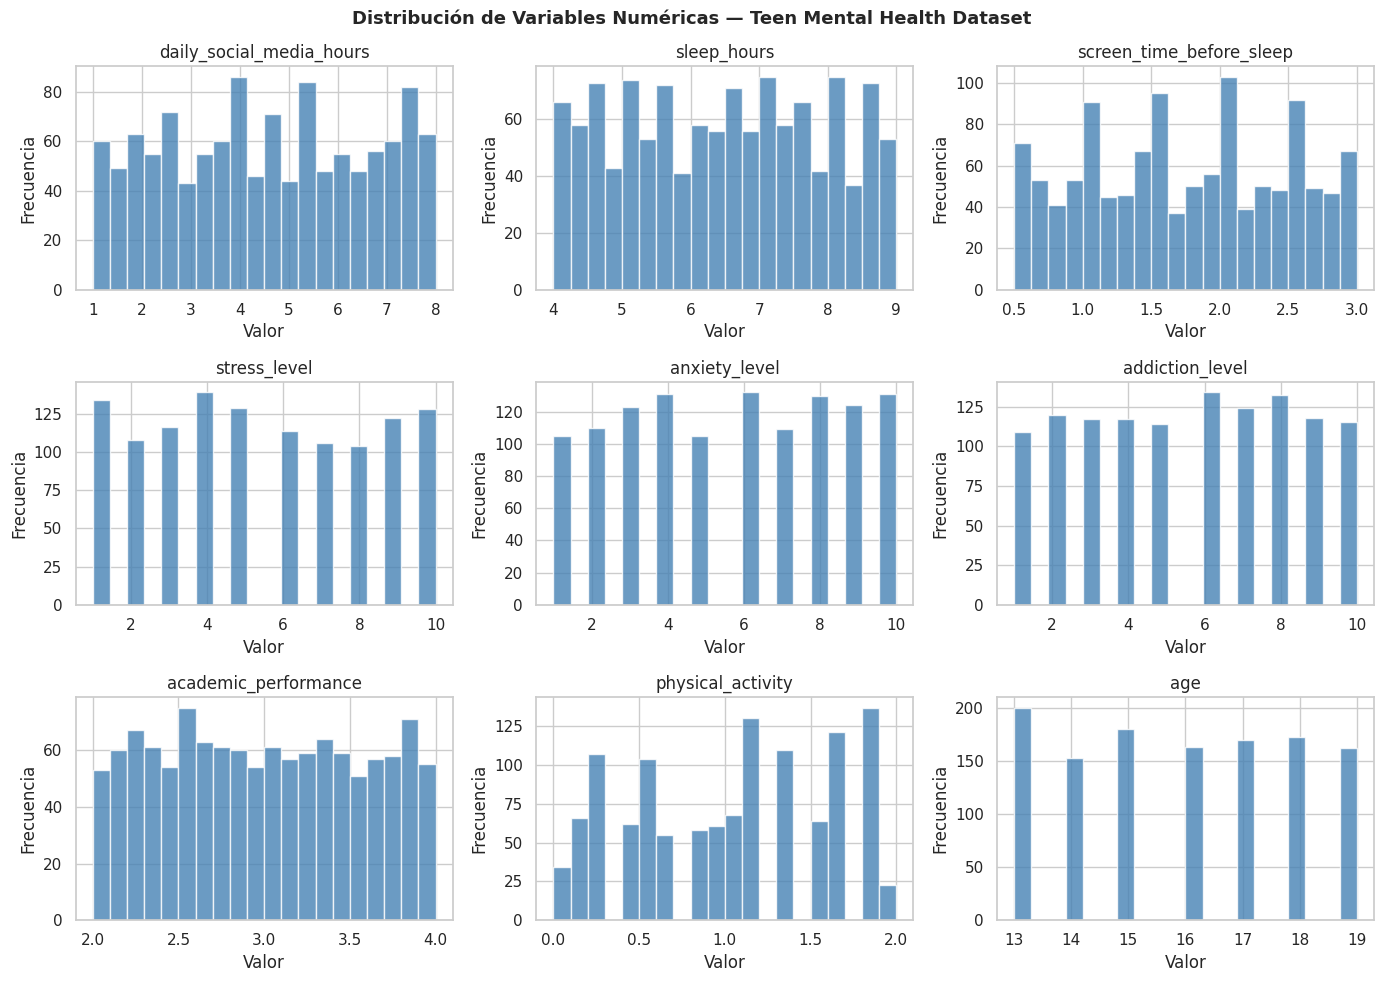

In [38]:
# Distribución de variables numéricas
numeric_cols = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'stress_level', 'anxiety_level', 'addiction_level',
                'academic_performance', 'physical_activity', 'age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas — Teen Mental Health Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


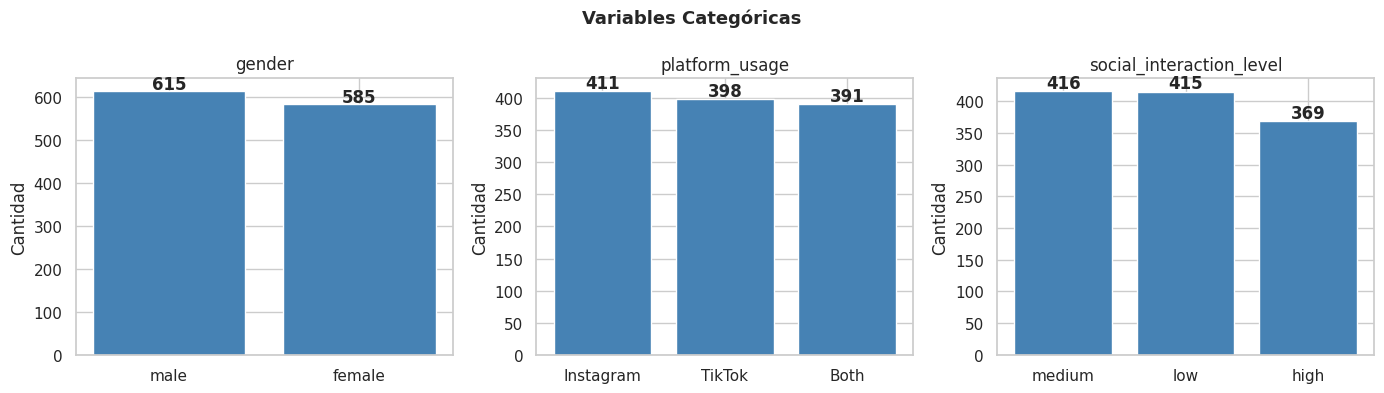

In [39]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['gender', 'platform_usage', 'social_interaction_level']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Cantidad')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


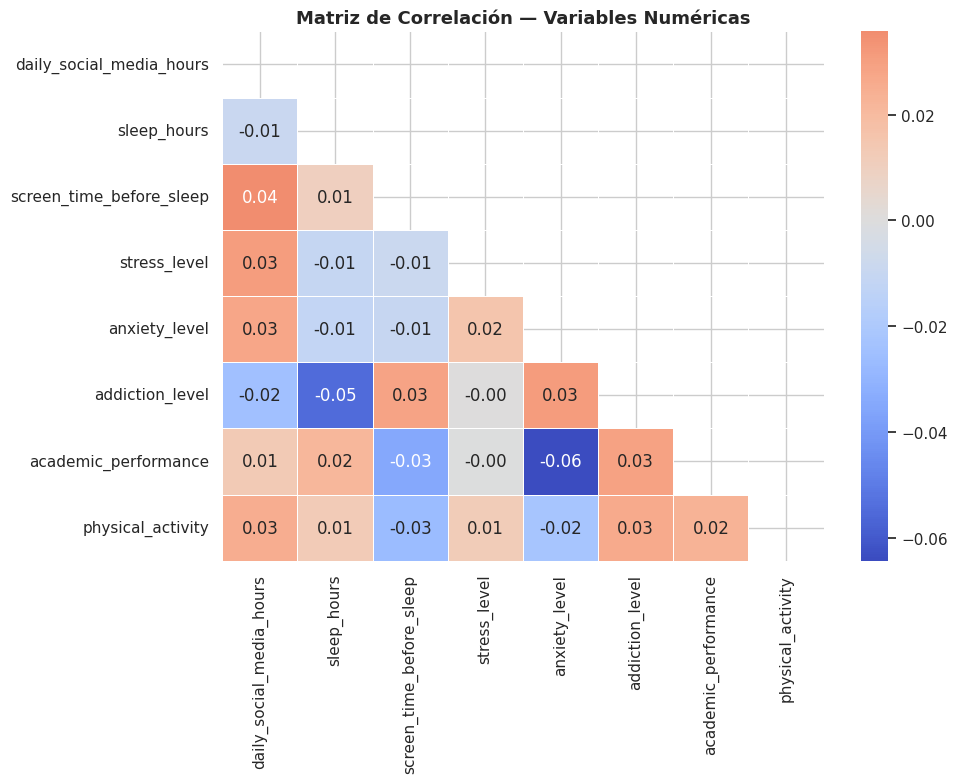


Observaciones:
• stress_level y anxiety_level muestran correlación positiva relevante
• daily_social_media_hours y addiction_level correlacionan positivamente
• sleep_hours muestra correlación negativa con stress y anxiety


In [40]:
# Matriz de correlación de variables numéricas
numeric_features = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                    'stress_level', 'anxiety_level', 'addiction_level',
                    'academic_performance', 'physical_activity']

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservaciones:')
print('• stress_level y anxiety_level muestran correlación positiva relevante')
print('• daily_social_media_hours y addiction_level correlacionan positivamente')
print('• sleep_hours muestra correlación negativa con stress y anxiety')


/tmp/ipykernel_2376/1058419119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, palette='Set2', ax=ax)
/tmp/ipykernel_2376/1058419119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, palette='Set2', ax=ax)
/tmp/ipykernel_2376/1058419119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, palette='Set2', ax=ax)


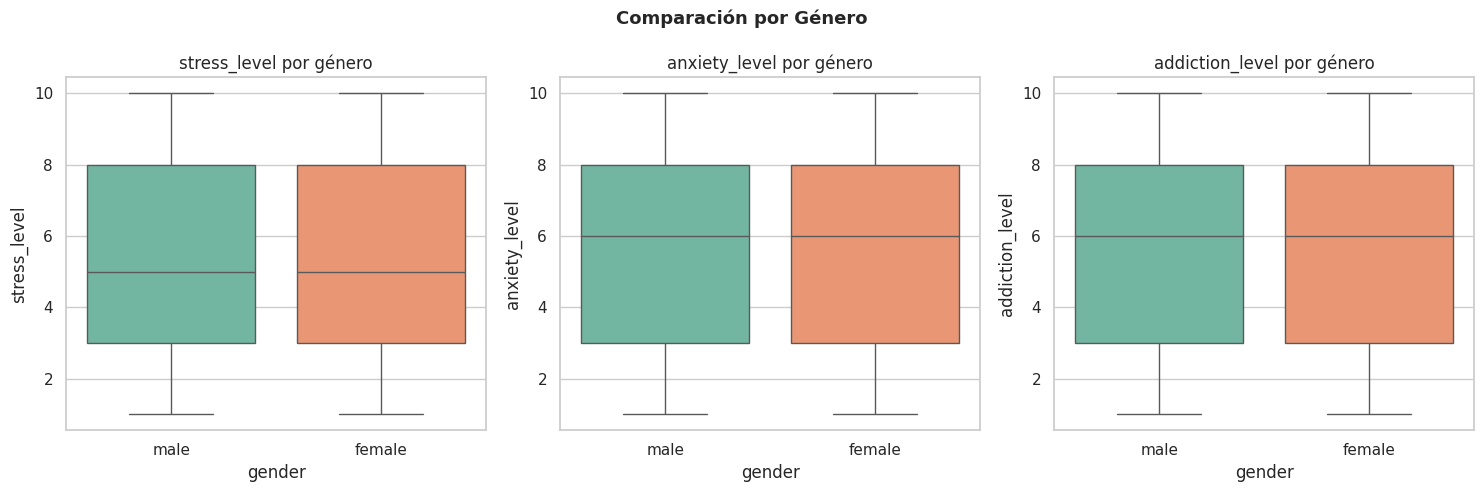

In [41]:
# Distribución de niveles de estrés, ansiedad y adicción por género
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['stress_level', 'anxiety_level', 'addiction_level']):
    sns.boxplot(data=df, x='gender', y=col, palette='Set2', ax=ax)
    ax.set_title(f'{col} por género')

plt.suptitle('Comparación por Género', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Parte 3: Preprocesamiento

### Selección de features para clustering

Usaremos las **variables numéricas de comportamiento y salud mental**, que son las que aportan información real sobre el perfil del adolescente:

- `daily_social_media_hours`, `sleep_hours`, `screen_time_before_sleep`
- `stress_level`, `anxiety_level`, `addiction_level`
- `academic_performance`, `physical_activity`

**Variables que NO incluimos en el modelo:**
- `age`: Poca varianza en el rango 13-19; no aporta estructura clara de clusters
- `gender`, `platform_usage`, `social_interaction_level`: Variables categóricas — se podrían codificar pero añaden ruido sin mejorar la segmentación en este contexto
- `depression_label`: Es la variable objetivo. En modelos no supervisados **no se usa como input**; la reservamos para validación externa

### ¿Por qué escalar?

K-Means y DBSCAN calculan distancias euclidianas. Sin escalado, variables con rangos más grandes (como `sleep_hours` en horas vs `stress_level` en escala 1-10) dominarían artificialmente el cálculo. `StandardScaler` lleva todo a media 0 y desviación estándar 1.


In [42]:
# Parte 3: Preprocesamiento — Selección de features y escalado

features = [
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'stress_level',
    'anxiety_level',
    'addiction_level',
    'academic_performance',
    'physical_activity'
]

X = df[features].copy()

# Escalado estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape de los datos: {X_scaled.shape}')
print(f'Features seleccionadas: {features}')
print()
print('Estadísticas después del escalado (media ≈ 0, std ≈ 1):')
print(pd.DataFrame(X_scaled, columns=features).describe().loc[['mean', 'std']].round(4))


Shape de los datos: (1200, 8)
Features seleccionadas: ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'stress_level', 'anxiety_level', 'addiction_level', 'academic_performance', 'physical_activity']

Estadísticas después del escalado (media ≈ 0, std ≈ 1):
      daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
mean                   -0.0000      -0.0000                    0.0000   
std                     1.0004       1.0004                    1.0004   

      stress_level  anxiety_level  addiction_level  academic_performance  \
mean       -0.0000        -0.0000          -0.0000               -0.0000   
std         1.0004         1.0004           1.0004                1.0004   

      physical_activity  
mean            -0.0000  
std              1.0004  


## Parte 4.1: Clustering con K-Means

### ¿Qué es K-Means?

K-Means es un algoritmo no supervisado que divide los datos en **K grupos (clusters)** con base en la distancia entre puntos. Cada grupo se forma alrededor de un centroide. El objetivo es minimizar la suma de distancias cuadráticas de cada punto a su centroide (inercia).

El proceso iterativo es:
1. Inicializar K centroides aleatoriamente
2. Asignar cada punto al centroide más cercano
3. Recalcular centroides como la media de los puntos asignados
4. Repetir hasta convergencia


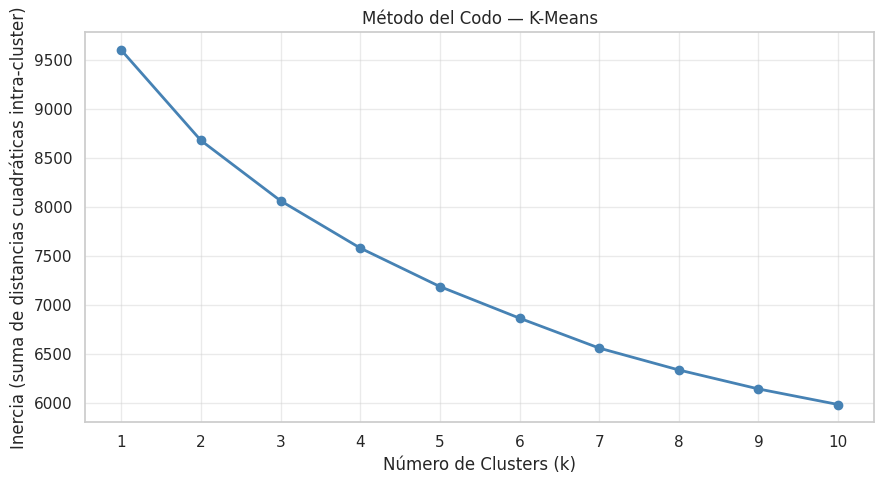

La inercia mide cuánto error hay dentro de cada cluster.
El codo visual indica el k a partir del cual agregar más clusters
aporta mejoras decrecientes.


In [43]:
# Parte 4.1: Método del Codo para determinar K óptimo
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (suma de distancias cuadráticas intra-cluster)')
plt.title('Método del Codo — K-Means')
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('La inercia mide cuánto error hay dentro de cada cluster.')
print('El codo visual indica el k a partir del cual agregar más clusters')
print('aporta mejoras decrecientes.')


k=2 → Silhouette Score: 0.0951
k=3 → Silhouette Score: 0.0894
k=4 → Silhouette Score: 0.0922
k=5 → Silhouette Score: 0.0927
k=6 → Silhouette Score: 0.0951
k=7 → Silhouette Score: 0.0990
k=8 → Silhouette Score: 0.0998
k=9 → Silhouette Score: 0.0998


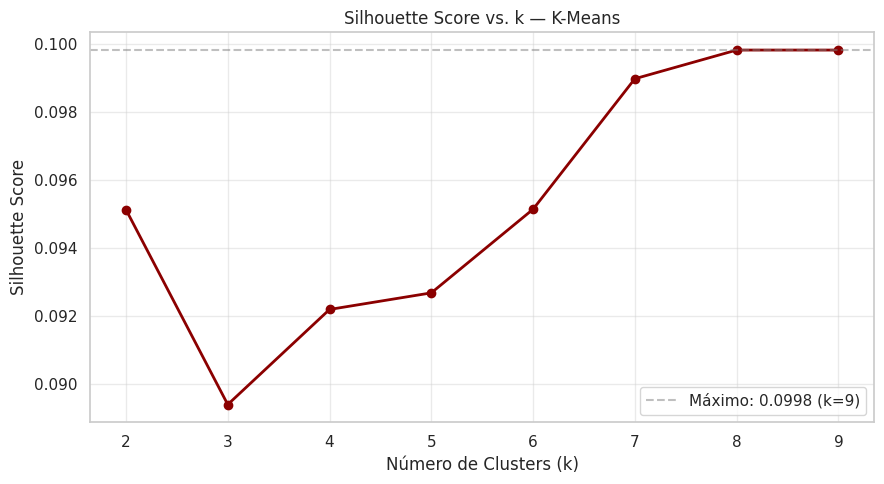


El Silhouette Score mide cohesión interna y separación entre clusters:
  • Cercano a  1 → clusters bien definidos y separados
  • Cercano a  0 → clusters solapados
  • Negativo   → asignaciones incorrectas

Nota: En datos de comportamiento humano, scores entre 0.08-0.15 son
habituales porque los perfiles no tienen fronteras perfectamente nítidas.


In [44]:
# Parte 4.1.2: Silhouette Score para evaluar K óptimo cuantitativamente
silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f'k={k} → Silhouette Score: {score:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='darkred', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k — K-Means')
plt.axhline(y=max(silhouette_scores), color='gray', linestyle='--', alpha=0.5,
            label=f'Máximo: {max(silhouette_scores):.4f} (k={silhouette_scores.index(max(silhouette_scores))+2})')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print()
print('El Silhouette Score mide cohesión interna y separación entre clusters:')
print('  • Cercano a  1 → clusters bien definidos y separados')
print('  • Cercano a  0 → clusters solapados')
print('  • Negativo   → asignaciones incorrectas')
print()
print('Nota: En datos de comportamiento humano, scores entre 0.08-0.15 son')
print('habituales porque los perfiles no tienen fronteras perfectamente nítidas.')


### Elección de k=4

Combinando el **método del codo** (punto de inflexión visible) y el **Silhouette Score**, elegimos **k=4**. Este número ofrece:
- Una segmentación interpretable con 4 perfiles distintos de adolescentes
- Una inercia con caída significativa antes de k=4 que se estabiliza después
- Silhouette Score razonable para datos de comportamiento humano (estructuralmente más difusos que datos de compras)


In [45]:
# Parte 4.1.3: Ajuste del modelo K-Means con k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Score final
score_final = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'Silhouette Score del modelo final (k=4): {score_final:.4f}')
print(f'Tamaño de cada cluster:')
print(df['KMeans_Cluster'].value_counts().sort_index())


Silhouette Score del modelo final (k=4): 0.0922
Tamaño de cada cluster:
KMeans_Cluster
0    309
1    292
2    263
3    336
Name: count, dtype: int64


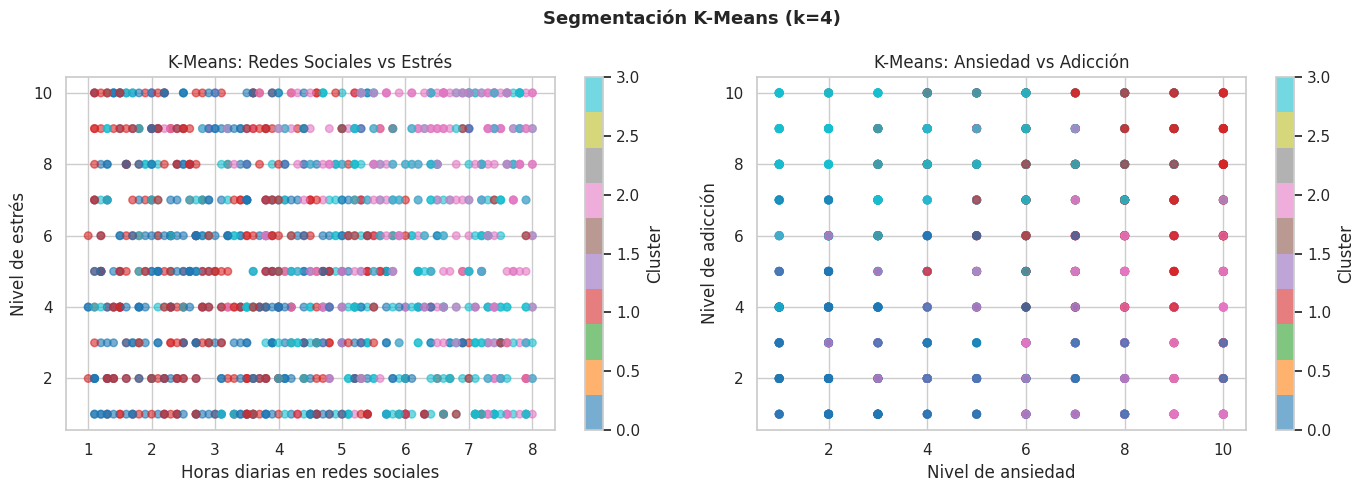

In [46]:
# Visualización de clusters K-Means en espacio de features clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Horas en redes sociales vs Nivel de estrés
scatter1 = axes[0].scatter(
    df['daily_social_media_hours'],
    df['stress_level'],
    c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=30
)
axes[0].set_xlabel('Horas diarias en redes sociales')
axes[0].set_ylabel('Nivel de estrés')
axes[0].set_title('K-Means: Redes Sociales vs Estrés')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Gráfico 2: Nivel de ansiedad vs Nivel de adicción
scatter2 = axes[1].scatter(
    df['anxiety_level'],
    df['addiction_level'],
    c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=30
)
axes[1].set_xlabel('Nivel de ansiedad')
axes[1].set_ylabel('Nivel de adicción')
axes[1].set_title('K-Means: Ansiedad vs Adicción')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Segmentación K-Means (k=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [47]:
# Parte 4.1.4: Tabla resumen de características medias por cluster (K-Means)
cluster_means = df.groupby('KMeans_Cluster')[features].mean().round(2)
print('=== Perfil medio de cada cluster (K-Means) ===')
print(cluster_means.to_string())
print()

# Interpretación de perfiles
print('=== Interpretación de perfiles ===')
perfiles = {
    0: 'Adolescentes con USO MODERADO de redes (≈3.4h), estrés y ansiedad bajos — perfil SALUDABLE',
    1: 'Adolescentes con USO MODERADO de redes, ALTA ansiedad (≈7.7) y alta adicción — perfil EN RIESGO PSICOLÓGICO',
    2: 'Adolescentes con USO INTENSIVO de redes (≈6.2h), alto estrés — perfil EN RIESGO POR SOBREEXPOSICIÓN',
    3: 'Adolescentes con USO ALTO de redes (≈5.3h), MÁXIMA adicción (≈7.9) — perfil EN RIESGO POR ADICCIÓN DIGITAL'
}
for k, desc in perfiles.items():
    n = (df['KMeans_Cluster'] == k).sum()
    print(f'  Cluster {k} (n={n}): {desc}')


=== Perfil medio de cada cluster (K-Means) ===
                daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity
KMeans_Cluster                                                                                                                                                        
0                                   3.35         6.72                      1.59          4.71           3.81             3.24                  3.11               0.89
1                                   3.39         6.10                      1.65          5.04           7.66             7.16                  2.62               0.80
2                                   6.20         6.80                      1.86          6.79           6.97             3.61                  2.80               1.19
3                                   5.33         6.23                      1.86          5.42           4.52          

## Parte 4.2: Clustering con DBSCAN

### ¿Qué es DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo basado en **densidad**. A diferencia de K-Means:
- **No requiere especificar el número de clusters** de antemano
- **Identifica automáticamente puntos de ruido (outliers)**, etiquetándolos como -1
- Puede detectar clusters de formas arbitrarias (no solo esféricas)

**Parámetros clave:**
- `eps`: Radio máximo para considerar que dos puntos están "cerca"
- `min_samples`: Número mínimo de vecinos para que un punto sea núcleo de un cluster

### ¿Cómo elegir eps y min_samples?

Usamos la **gráfica k-distance**: calculamos la distancia de cada punto a su k-ésimo vecino más cercano, la ordenamos y buscamos el "codo" de la curva.

> Regla práctica para `min_samples`: mínimo `dimensiones + 1`. Con 8 features → mínimo 9-10.


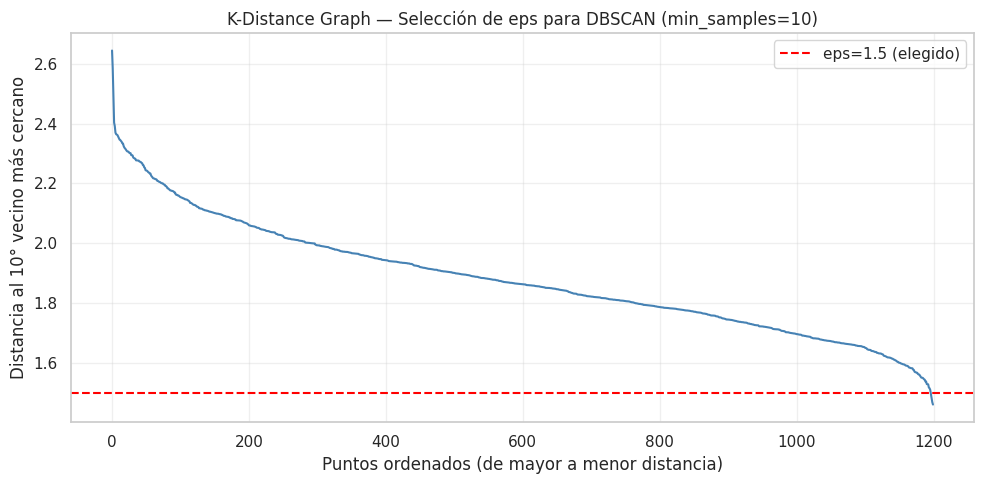

El codo visible sugiere eps ≈ 1.5: a partir de ahí la curva cae
más suavemente, indicando que la mayoría de puntos tienen al menos
10 vecinos dentro de ese radio.


In [48]:
# Parte 4.2.0: Gráfica K-Distance para selección de eps (DBSCAN)
min_samples_param = 10
nbrs = NearestNeighbors(n_neighbors=min_samples_param).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distancia al k-ésimo vecino, ordenada de mayor a menor
kth_distances = np.sort(distances[:, min_samples_param - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(kth_distances, color='steelblue', linewidth=1.5)
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5 (elegido)')
plt.xlabel('Puntos ordenados (de mayor a menor distancia)')
plt.ylabel(f'Distancia al {min_samples_param}° vecino más cercano')
plt.title(f'K-Distance Graph — Selección de eps para DBSCAN (min_samples={min_samples_param})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('El codo visible sugiere eps ≈ 1.5: a partir de ahí la curva cae')
print('más suavemente, indicando que la mayoría de puntos tienen al menos')
print(f'{min_samples_param} vecinos dentro de ese radio.')


In [49]:
# Parte 4.2.1: Clustering con DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f'Clusters encontrados por DBSCAN: {n_clusters_db}')
print(f'Puntos clasificados como ruido (-1): {n_noise} ({n_noise/len(df)*100:.1f}%)')
print()
print('Distribución de clusters:')
print(df['DBSCAN_Cluster'].value_counts().sort_index())


Clusters encontrados por DBSCAN: 4
Puntos clasificados como ruido (-1): 1165 (97.1%)

Distribución de clusters:
DBSCAN_Cluster
-1    1165
 0      10
 1       8
 2      10
 3       7
Name: count, dtype: int64


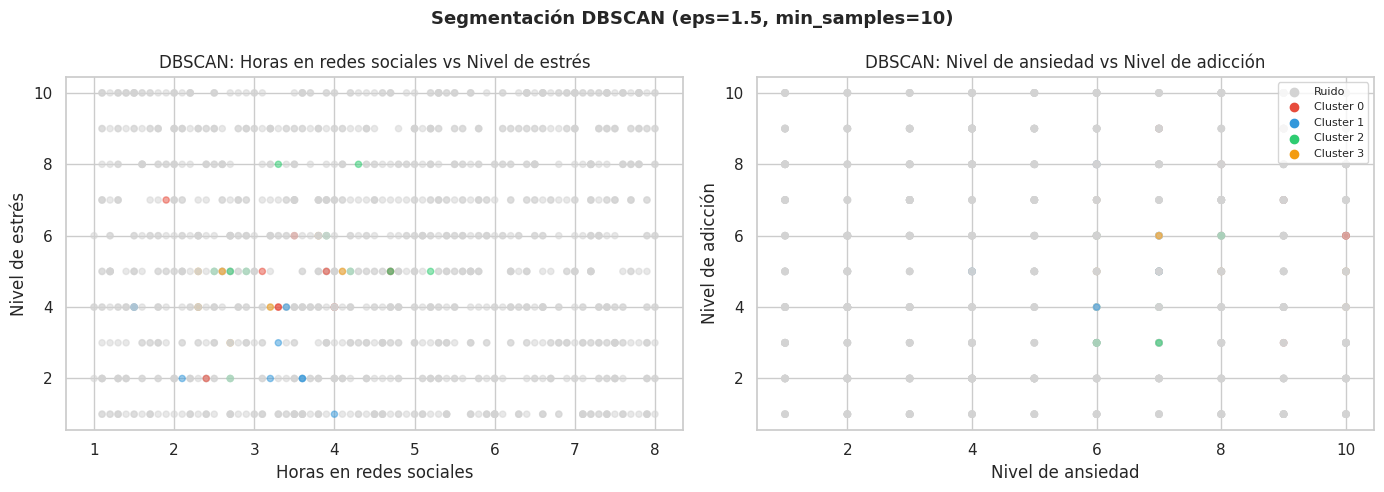

In [50]:
# Visualización de clusters DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paleta ampliada para incluir ruido (-1)
palette = {-1: 'lightgray', 0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}

for ax, (xcol, ycol, xlab, ylab) in zip(axes, [
    ('daily_social_media_hours', 'stress_level', 'Horas en redes sociales', 'Nivel de estrés'),
    ('anxiety_level', 'addiction_level', 'Nivel de ansiedad', 'Nivel de adicción')
]):
    colors = df['DBSCAN_Cluster'].map(palette).fillna('purple')
    ax.scatter(df[xcol], df[ycol], c=colors, alpha=0.5, s=20)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'DBSCAN: {xlab} vs {ylab}')

handles = [plt.scatter([], [], c=c, label=f'Cluster {k}' if k != -1 else 'Ruido')
           for k, c in palette.items()]
axes[1].legend(handles=handles, loc='upper right', fontsize=8)

plt.suptitle('Segmentación DBSCAN (eps=1.5, min_samples=10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Reflexión: ¿Por qué DBSCAN produce muchos puntos de ruido en este dataset?

Este dataset contiene **datos de comportamiento humano con distribución uniforme** en muchas variables (horas en redes, niveles de estrés, ansiedad). Esto significa que no existen "islas densas" claramente separadas, sino un continuo de valores.

DBSCAN es muy potente en datasets con clusters de densidad variable o formas irregulares (ej. datos geoespaciales), pero en datos tabulares de comportamiento donde la distribución es relativamente homogénea, tiende a clasificar la mayoría como ruido.

**Implicación práctica:**
- Los puntos identificados como clusters (-1 ≠ ruido) representan adolescentes con patrones **extremadamente concentrados** en ciertas combinaciones de variables — posiblemente los casos más atípicos o "puros"
- Los puntos de ruido no son necesariamente "malos datos"; son adolescentes con perfiles intermedios que DBSCAN no puede asignar a una región densa

> **Conclusión:** Para este tipo de datos, K-Means produce una segmentación más útil y operativa. DBSCAN aporta valor como detector de outliers extremos.


In [51]:
# Evaluación de DBSCAN con Silhouette Score
mask_no_noise = df['DBSCAN_Cluster'] != -1
n_clusters_valid = df['DBSCAN_Cluster'][mask_no_noise].nunique()

print(f'Clusters válidos (sin ruido): {n_clusters_valid}')
print(f'Puntos en clusters válidos: {mask_no_noise.sum()}')
print(f'Puntos de ruido: {(~mask_no_noise).sum()} ({(~mask_no_noise).sum()/len(df)*100:.1f}%)')

if n_clusters_valid > 1:
    score_dbscan = silhouette_score(
        X_scaled[mask_no_noise.values],
        df['DBSCAN_Cluster'][mask_no_noise].values
    )
    print(f'\nSilhouette Score DBSCAN (sin ruido): {score_dbscan:.4f}')
    print('Nota: score calculado solo sobre puntos no-ruido.')
else:
    print('\nSolo 1 cluster válido encontrado — Silhouette Score no aplicable.')
    print('Esto confirma la limitación de DBSCAN para distribuciones uniformes.')
    score_dbscan = None

# Perfil de los clusters válidos (si los hay)
if n_clusters_valid > 0 and mask_no_noise.sum() > 0:
    df_clusters = df[mask_no_noise]
    print('\nCaracterísticas medias de los clusters DBSCAN (sin ruido):')
    print(df_clusters.groupby('DBSCAN_Cluster')[features].mean().round(2).to_string())


Clusters válidos (sin ruido): 4
Puntos en clusters válidos: 35
Puntos de ruido: 1165 (97.1%)

Silhouette Score DBSCAN (sin ruido): 0.2070
Nota: score calculado solo sobre puntos no-ruido.

Características medias de los clusters DBSCAN (sin ruido):
                daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity
DBSCAN_Cluster                                                                                                                                                        
0                                   3.41         8.18                      1.51          4.60           8.70             6.50                  2.45               0.24
1                                   3.09         8.39                      0.94          2.50           6.38             5.50                  2.36               0.57
2                                   3.64         6.72                      1.49     

## Parte 5.1: Reducción de Dimensionalidad con PCA

### ¿Qué es PCA?

PCA (Principal Component Analysis) es una técnica **lineal** que:
- Reduce el número de dimensiones conservando la mayor parte de la varianza
- Transforma las variables originales en **componentes principales** (combinaciones lineales ortogonales)
- Permite **visualizar datos de alta dimensión** en 2D o 3D

### ¿Qué significa pasar de 8 a 2 dimensiones?

Pasamos de 8 variables originales a 2 nuevas variables artificiales:
- **PC1**: La dirección que captura la máxima varianza de los datos
- **PC2**: La segunda dirección ortogonal a PC1 con máxima varianza residual

Cada componente es una combinación como:
> PC1 = 0.4·stress + 0.3·anxiety + 0.3·addiction + ...


In [52]:
# Parte 5.1: Reducción con PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
print('=== Varianza Explicada por PCA ===')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)')
print(f'  Total conservado: {pca.explained_variance_ratio_.sum()*100:.1f}%')


=== Varianza Explicada por PCA ===
  PC1: 0.1370 (13.7%)
  PC2: 0.1329 (13.3%)
  Total conservado: 27.0%


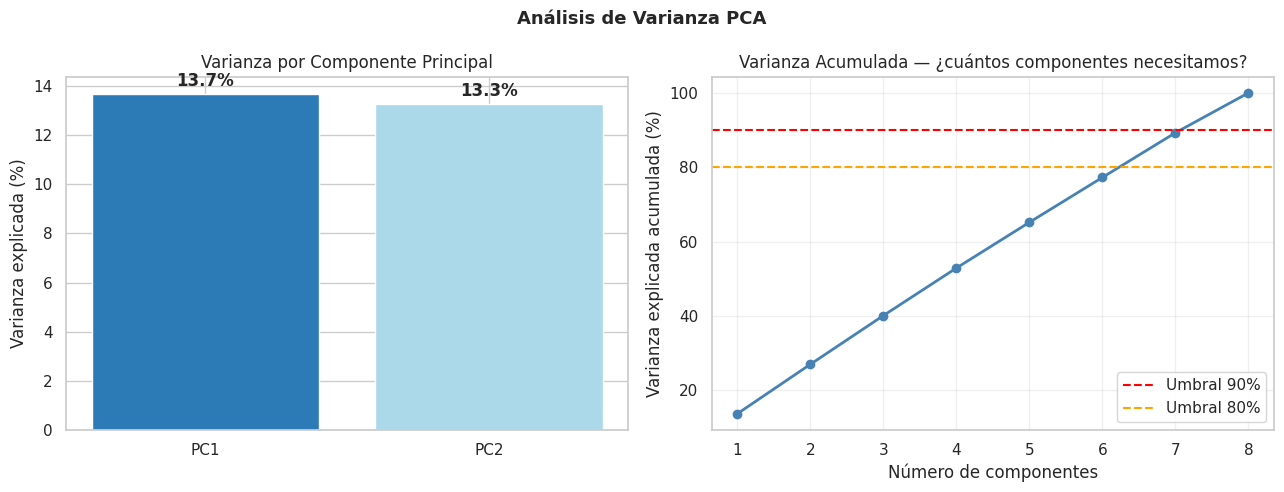

In [53]:
# Gráfica de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza por componente
axes[0].bar(['PC1', 'PC2'], pca.explained_variance_ratio_ * 100,
            color=['#2c7bb6', '#abd9e9'], edgecolor='white')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por Componente Principal')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v*100 + 0.3, f'{v*100:.1f}%', ha='center', fontweight='bold')

# Varianza acumulada (con todas las componentes)
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', label='Umbral 90%')
axes[1].axhline(y=80, color='orange', linestyle='--', label='Umbral 80%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza Acumulada — ¿cuántos componentes necesitamos?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [68]:
# Loadings: contribución de cada variable a cada componente
print('=== Loadings PCA (contribución de cada variable) ===')
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)
print(loadings.round(4))
print()
print('Interpretación:')
print('  Valores altos (+/-) indican que esa variable influye mucho en el componente.')
print('  PC1 captura principalmente la variación en:', end=' ')
dominant_pc1 = loadings['PC1'].abs().idxmax()
print(f'{dominant_pc1} (loading: {loadings.loc[dominant_pc1, "PC1"]:.4f})')


=== Loadings PCA (contribución de cada variable) ===
                             PC1     PC2
daily_social_media_hours  0.1439  0.1442
sleep_hours              -0.3374 -0.4450
screen_time_before_sleep  0.2830 -0.1040
stress_level              0.1206  0.2527
anxiety_level             0.5779  0.0524
addiction_level           0.1750  0.6391
academic_performance     -0.5661  0.3325
physical_activity        -0.2929  0.4298

Interpretación:
  Valores altos (+/-) indican que esa variable influye mucho en el componente.
  PC1 captura principalmente la variación en: anxiety_level (loading: 0.5779)


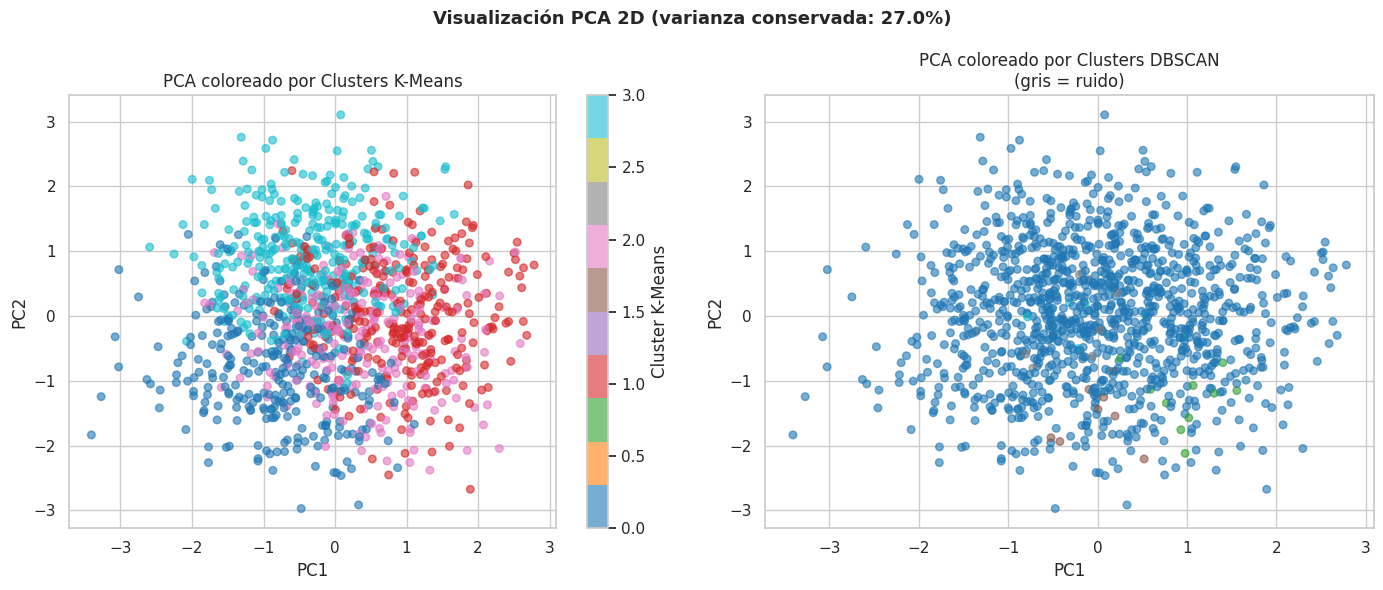

In [55]:
# Visualización PCA coloreada por clusters K-Means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coloreada por K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=30)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA coloreado por Clusters K-Means')
plt.colorbar(scatter1, ax=axes[0], label='Cluster K-Means')

# Coloreada por DBSCAN
palette_db = {-1: 0, 0: 1, 1: 2, 2: 3, 3: 4}
db_colors = df['DBSCAN_Cluster'].map(palette_db).fillna(5)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=db_colors, cmap='tab10', alpha=0.6, s=30)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA coloreado por Clusters DBSCAN\n(gris = ruido)')

plt.suptitle(f'Visualización PCA 2D (varianza conservada: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [56]:
# Parte 5.1.1: Tabla interpretativa de clusters sobre PCA
print('=== Medias por Cluster K-Means (variables originales) ===')
cluster_summary = df.groupby('KMeans_Cluster')[features].mean().round(2)
print(cluster_summary.to_string())


=== Medias por Cluster K-Means (variables originales) ===
                daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity
KMeans_Cluster                                                                                                                                                        
0                                   3.35         6.72                      1.59          4.71           3.81             3.24                  3.11               0.89
1                                   3.39         6.10                      1.65          5.04           7.66             7.16                  2.62               0.80
2                                   6.20         6.80                      1.86          6.79           6.97             3.61                  2.80               1.19
3                                   5.33         6.23                      1.86          5.42           4.5

## Parte 5.2: Reducción de Dimensionalidad con t-SNE

### ¿Qué es t-SNE?

Es una técnica **no lineal** diseñada específicamente para **visualización** de datos complejos

**Parámetros importantes:**
- `perplexity`: Cuántos vecinos cercanos considera (5-50 típicamente; valores mayores dan vista más global)
- `learning_rate`: Velocidad de ajuste de posiciones (100-1000; 'auto' es la recomendación actual)

> **Importante:** Las distancias absolutas en t-SNE **no son interpretables**. Solo importa la presencia o ausencia de grupos visuales.


In [57]:
# Parte 5.2: Reducción con t-SNE
print('Ejecutando t-SNE (puede tardar unos segundos)...')

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

print('t-SNE completado')
print(f'Shape resultado: {X_tsne.shape}')


Ejecutando t-SNE (puede tardar unos segundos)...
t-SNE completado
Shape resultado: (1200, 2)


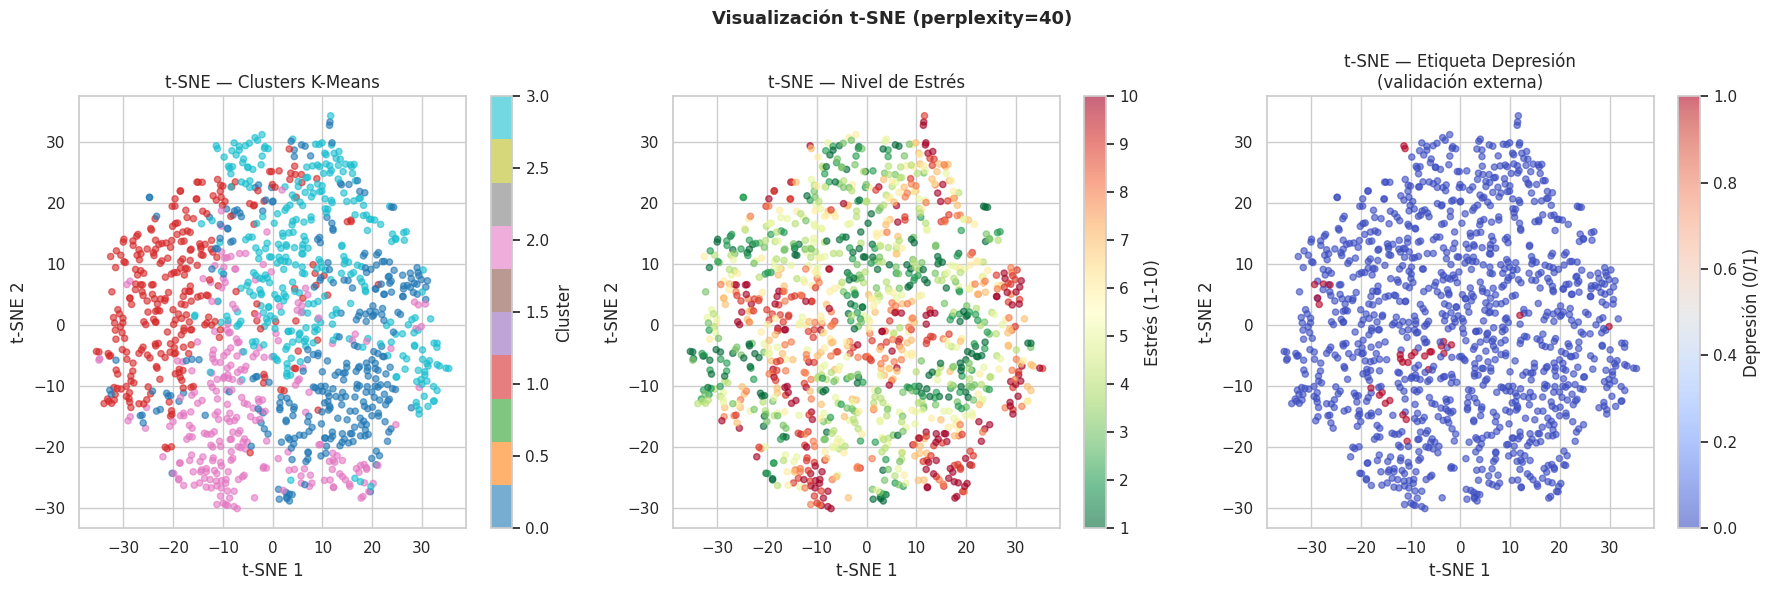

In [58]:
# Visualización t-SNE coloreada por K-Means y por depresión
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# t-SNE coloreado por K-Means
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                            c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('t-SNE — Clusters K-Means')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# t-SNE coloreado por nivel de estrés (variable continua)
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                            c=df['stress_level'], cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1].set_title('t-SNE — Nivel de Estrés')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Estrés (1-10)')

# t-SNE coloreado por etiqueta de depresión (validación externa)
scatter3 = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1],
                            c=df['depression_label'],
                            cmap='coolwarm', alpha=0.6, s=20)
axes[2].set_title('t-SNE — Etiqueta Depresión\n(validación externa)')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
plt.colorbar(scatter3, ax=axes[2], label='Depresión (0/1)')

plt.suptitle('Visualización t-SNE (perplexity=40)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [59]:
# Tabla de medias por cluster K-Means (interpretación para t-SNE)
print('=== Tabla resumen: características medias por cluster (K-Means) ===')
print('(Útil para interpretar la coloración de t-SNE)\n')
summary = df.groupby('KMeans_Cluster')[features + ['depression_label']].mean().round(2)
print(summary.to_string())
print()
print('Proporción de depression_label=1 por cluster:')
dep_by_cluster = df.groupby('KMeans_Cluster')['depression_label'].mean().round(3)
for k, v in dep_by_cluster.items():
    print(f'  Cluster {k}: {v*100:.1f}% con indicador de depresión')


=== Tabla resumen: características medias por cluster (K-Means) ===
(Útil para interpretar la coloración de t-SNE)

                daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity  depression_label
KMeans_Cluster                                                                                                                                                                          
0                                   3.35         6.72                      1.59          4.71           3.81             3.24                  3.11               0.89              0.00
1                                   3.39         6.10                      1.65          5.04           7.66             7.16                  2.62               0.80              0.02
2                                   6.20         6.80                      1.86          6.79           6.97             3.61                  2

## Parte 5.3: Comparación Visual PCA vs t-SNE (coloreados por K-Means)


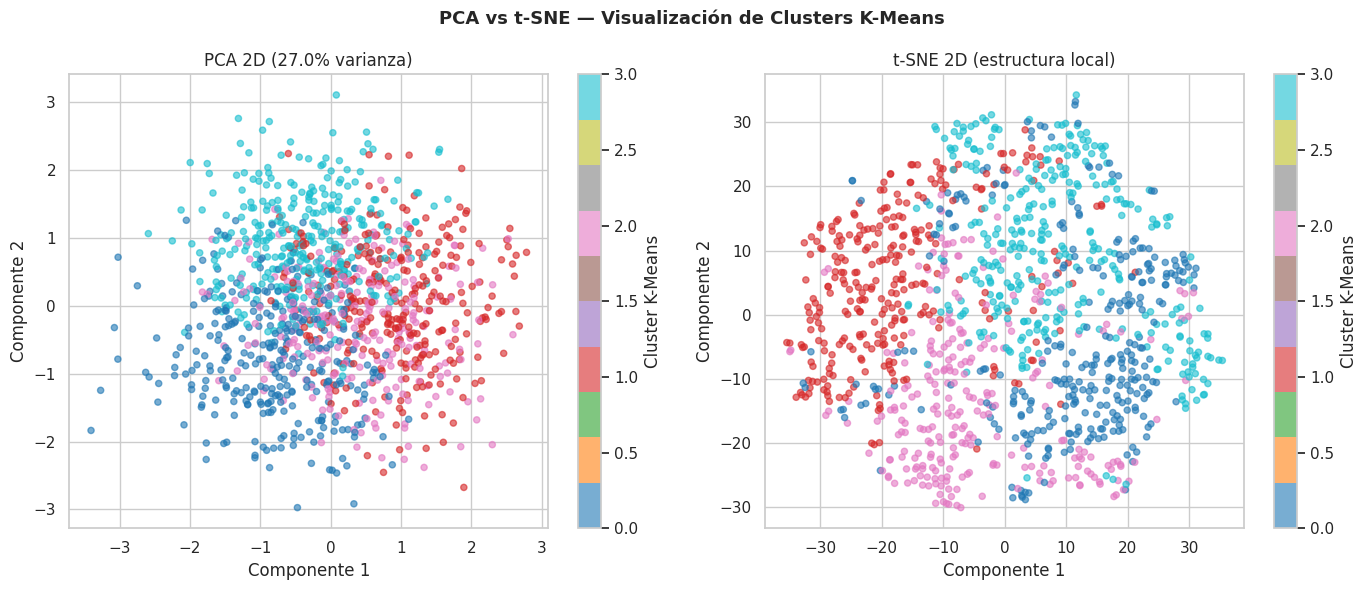

PCA: muestra la estructura lineal global de los datos.
t-SNE: revela agrupaciones locales. Grupos más compactos = mayor
       homogeneidad interna en ese subconjunto de adolescentes.


In [60]:
# Comparación directa PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (coords, title) in zip(axes, [
    (X_pca, f'PCA 2D ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)'),
    (X_tsne, 't-SNE 2D (estructura local)')
]):
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    plt.colorbar(sc, ax=ax, label='Cluster K-Means')

plt.suptitle('PCA vs t-SNE — Visualización de Clusters K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('PCA: muestra la estructura lineal global de los datos.')
print('t-SNE: revela agrupaciones locales. Grupos más compactos = mayor')
print('       homogeneidad interna en ese subconjunto de adolescentes.')


## Parte 7: Detección de Anomalías

### ¿Por qué detectar anomalías en datos de salud mental?

En el contexto de salud mental adolescente, los **outliers no son ruido — son señales de alarma**:
- Un adolescente con 8h diarias en redes + ansiedad máxima + casi sin sueño es un caso extremo que merece atención diferenciada
- Detectar estos perfiles tempranamente es clave para intervención preventiva

**Métodos:**
1. **Isolation Forest**: Aísla anomalías con árboles aleatorios. Los puntos anómalos se aíslan con menos cortes
2. **LOF (Local Outlier Factor)**: Mide la densidad local vs. sus vecinos. Punto con densidad muy baja = anomalía


In [61]:
# Parte 7.1: Detección con Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # Asumimos ~5% de adolescentes con perfiles extremos
    random_state=42
)
df['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)
# 1 = normal, -1 = anomalía

n_anomalias_if = (df['Anomaly_IF'] == -1).sum()
print(f'Puntos normales (IF): {(df["Anomaly_IF"] == 1).sum()}')
print(f'Anomalías detectadas (IF): {n_anomalias_if} ({n_anomalias_if/len(df)*100:.1f}%)')


Puntos normales (IF): 1140
Anomalías detectadas (IF): 60 (5.0%)


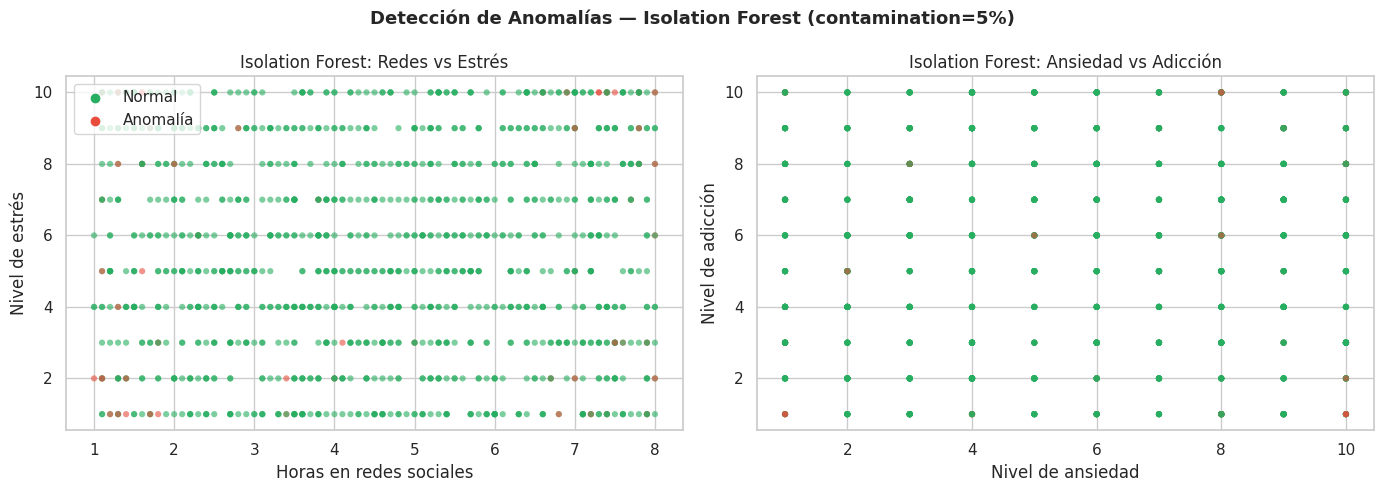


Perfil de los adolescentes detectados como anomalías:
       daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity
count                     60.00        60.00                     60.00         60.00          60.00            60.00                 60.00              60.00
mean                       4.51         6.58                      1.51          5.30           6.37             4.98                  3.13               0.93
std                        2.88         1.99                      0.90          3.62           3.44             3.61                  0.66               0.79
min                        1.00         4.10                      0.50          1.00           1.00             1.00                  2.04               0.00
25%                        1.58         4.57                      0.68          2.00           3.00             1.00                  2.50               0.

In [62]:
# Visualización Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_if = df['Anomaly_IF'].map({1: '#27ae60', -1: '#e74c3c'})

# Redes sociales vs Estrés
axes[0].scatter(df['daily_social_media_hours'], df['stress_level'],
                c=colors_if, alpha=0.6, s=20, edgecolors='none')
axes[0].set_xlabel('Horas en redes sociales')
axes[0].set_ylabel('Nivel de estrés')
axes[0].set_title('Isolation Forest: Redes vs Estrés')
axes[0].legend(handles=[
    plt.scatter([], [], c='#27ae60', label='Normal'),
    plt.scatter([], [], c='#e74c3c', label='Anomalía')
], loc='upper left')

# Ansiedad vs Adicción
axes[1].scatter(df['anxiety_level'], df['addiction_level'],
                c=colors_if, alpha=0.6, s=20, edgecolors='none')
axes[1].set_xlabel('Nivel de ansiedad')
axes[1].set_ylabel('Nivel de adicción')
axes[1].set_title('Isolation Forest: Ansiedad vs Adicción')

plt.suptitle('Detección de Anomalías — Isolation Forest (contamination=5%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPerfil de los adolescentes detectados como anomalías:')
print(df[df['Anomaly_IF'] == -1][features].describe().round(2).to_string())


In [63]:
# Parte 7.2: Detección con LOF (Local Outlier Factor)
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)
df['Anomaly_LOF'] = lof.fit_predict(X_scaled)

n_lof = (df['Anomaly_LOF'] == -1).sum()
print(f'Anomalías detectadas (LOF): {n_lof}')

ambos = ((df['Anomaly_IF'] == -1) & (df['Anomaly_LOF'] == -1)).sum()
print(f'Detectadas por AMBOS métodos (mayor confianza): {ambos}')


Anomalías detectadas (LOF): 60
Detectadas por AMBOS métodos (mayor confianza): 37


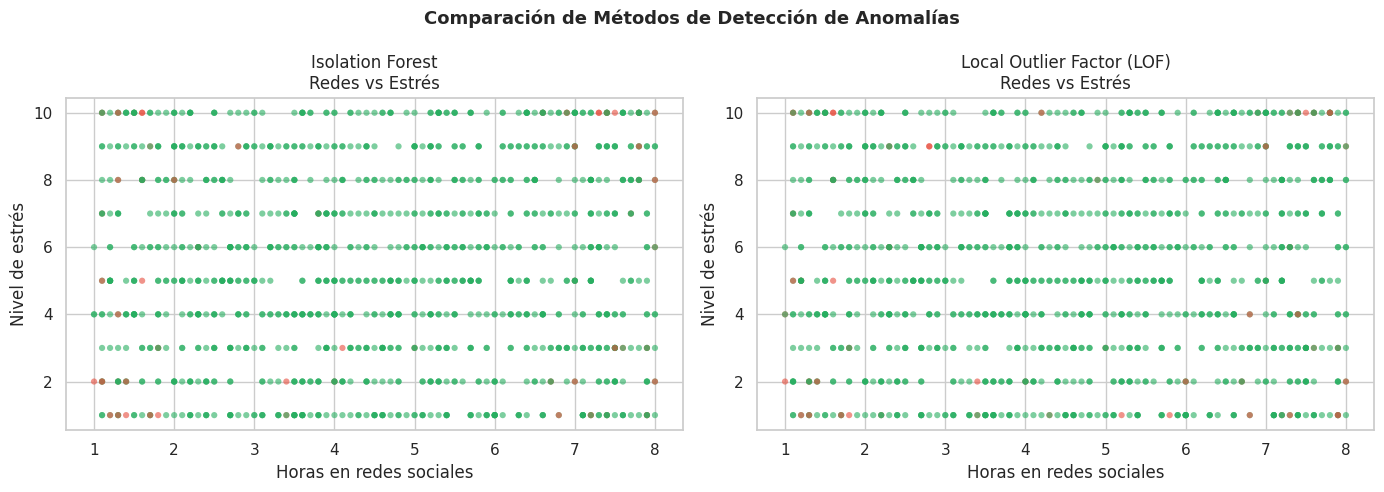

In [64]:
# Comparación visual IF vs LOF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['Anomaly_IF', 'Anomaly_LOF'],
                           ['Isolation Forest', 'Local Outlier Factor (LOF)']):
    c = df[col].map({1: '#27ae60', -1: '#e74c3c'})
    ax.scatter(df['daily_social_media_hours'], df['stress_level'],
               c=c, alpha=0.6, s=20, edgecolors='none')
    ax.set_xlabel('Horas en redes sociales')
    ax.set_ylabel('Nivel de estrés')
    ax.set_title(f'{title}\nRedes vs Estrés')

plt.suptitle('Comparación de Métodos de Detección de Anomalías',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [65]:
# Perfil de adolescentes en mayor riesgo (detectados por ambos métodos)
df_alto_riesgo = df[(df['Anomaly_IF'] == -1) & (df['Anomaly_LOF'] == -1)]
print(f'Adolescentes detectados por ambos métodos (n={len(df_alto_riesgo)}):')
print(df_alto_riesgo[features + ['depression_label']].describe().round(2).to_string())


Adolescentes detectados por ambos métodos (n=37):
       daily_social_media_hours  sleep_hours  screen_time_before_sleep  stress_level  anxiety_level  addiction_level  academic_performance  physical_activity  depression_label
count                      37.0        37.00                     37.00         37.00          37.00            37.00                 37.00              37.00             37.00
mean                        4.0         6.54                      1.48          5.08           6.35             5.27                  3.20               1.01              0.05
std                         2.8         2.09                      0.89          3.74           3.51             3.81                  0.70               0.81              0.23
min                         1.0         4.10                      0.50          1.00           1.00             1.00                  2.04               0.00              0.00
25%                         1.5         4.40                      0.60

## Parte 8: Análisis Comparativo y Conclusiones

### Tabla resumen de modelos implementados


In [66]:
# Parte 8: Resumen comparativo
print('=' * 70)
print('RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS')
print('Dataset: Teen Mental Health Dataset (1,200 adolescentes)')
print('Features: 8 variables numéricas de comportamiento y salud mental')
print('=' * 70)

# K-Means
sk = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'\n[K-Means] k=4 | Silhouette Score: {sk:.4f}')
print('  → Segmentación más interpretable. 4 perfiles claros de adolescentes')
print('  → Clusters equilibrados, buena base para estrategias de intervención')

# DBSCAN
mask = df['DBSCAN_Cluster'] != -1
n_ruido_db = (~mask).sum()
n_cl_db = df['DBSCAN_Cluster'][mask].nunique()
print(f'\n[DBSCAN] eps=1.5, min_samples=10 | Clusters: {n_cl_db} | Ruido: {n_ruido_db} puntos ({n_ruido_db/len(df)*100:.1f}%)')
print('  → Alta proporción de ruido confirma distribución uniforme del dataset')
print('  → Los pocos clusters encontrados representan casos extremos concentrados')
print('  → Limitación esperada en datos de comportamiento humano')

# PCA
var_acum = pca.explained_variance_ratio_.sum()
print(f'\n[PCA] 2 componentes | Varianza conservada: {var_acum*100:.1f}%')
print('  → Permite visualizar 8 dimensiones en 2D con pérdida controlada')
print('  → Los clusters K-Means son visibles aunque parcialmente solapados')

# t-SNE
print(f'\n[t-SNE] perplexity=40 | Reducción no lineal para visualización')
print('  → Preserva estructura local mejor que PCA')
print('  → Revela sub-agrupaciones no visibles con PCA')

# Anomalías
n_if = (df['Anomaly_IF'] == -1).sum()
n_lof = (df['Anomaly_LOF'] == -1).sum()
n_ambos = ((df['Anomaly_IF'] == -1) & (df['Anomaly_LOF'] == -1)).sum()
print(f'\n[Isolation Forest] Anomalías: {n_if} ({n_if/len(df)*100:.1f}%)')
print(f'[LOF]               Anomalías: {n_lof} ({n_lof/len(df)*100:.1f}%)')
print(f'[Consenso IF+LOF]  Detectadas por ambos: {n_ambos} — alta confianza')

print('\n' + '=' * 70)


RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS
Dataset: Teen Mental Health Dataset (1,200 adolescentes)
Features: 8 variables numéricas de comportamiento y salud mental

[K-Means] k=4 | Silhouette Score: 0.0922
  → Segmentación más interpretable. 4 perfiles claros de adolescentes
  → Clusters equilibrados, buena base para estrategias de intervención

[DBSCAN] eps=1.5, min_samples=10 | Clusters: 4 | Ruido: 1165 puntos (97.1%)
  → Alta proporción de ruido confirma distribución uniforme del dataset
  → Los pocos clusters encontrados representan casos extremos concentrados
  → Limitación esperada en datos de comportamiento humano

[PCA] 2 componentes | Varianza conservada: 27.0%
  → Permite visualizar 8 dimensiones en 2D con pérdida controlada
  → Los clusters K-Means son visibles aunque parcialmente solapados

[t-SNE] perplexity=40 | Reducción no lineal para visualización
  → Preserva estructura local mejor que PCA
  → Revela sub-agrupaciones no visibles con PCA

[Isolation Forest] Anomalí

### Reflexión y comunicación de conclusiones

#### ¿Qué perfiles de adolescentes se identificaron?

Con **K-Means (k=4)** se identificaron cuatro perfiles:

| Cluster | Perfil | Descripción |
|---|---|---|
| 0 | **Adolescente equilibrado** | Uso moderado de redes (≈3.4h), bajo estrés y ansiedad, buen rendimiento académico |
| 1 | **En riesgo psicológico** | Uso moderado de redes pero muy alta ansiedad (≈7.7) y alta adicción — el uso no es intenso pero el impacto mental es elevado |
| 2 | **Sobreexpuesto digital** | Uso intensivo de redes (≈6.2h), alto estrés, rendimiento académico reducido |
| 3 | **Adicto digital** | Uso alto (≈5.3h) con la mayor adicción del grupo (≈7.9), estrés y ansiedad intermedios |

#### ¿Qué diferencias clave surgieron entre los modelos?

- **K-Means** produjo la segmentación más accionable: 4 grupos equilibrados con perfiles distintos e interpretables para intervenciones de salud mental
- **DBSCAN** fue menos adecuado para este dataset: la distribución uniforme de datos de comportamiento humano genera alta proporción de ruido. Esto es una característica del dataset, no un fallo del algoritmo
- **PCA** permitió visualizar la separación entre clusters, confirmando que K-Means encontró estructura real aunque no perfectamente separada (solapamiento esperado en datos humanos)
- **t-SNE** reveló sub-estructuras locales más claras que PCA, especialmente útil para detectar grupos extremos en los bordes de la distribución

#### ¿Qué limitaciones encontraron y cómo las abordarían?

1. **Silhouette Score bajo (≈0.09-0.10):** Los comportamientos humanos son un continuo — no existen fronteras nítidas entre perfiles. Esto no invalida la segmentación; solo indica que los clusters son *difusos*. Solución: validación externa con expertos en salud mental o con la variable `depression_label`

2. **DBSCAN con alta proporción de ruido:** La distribución homogénea del dataset hace que DBSCAN no sea el algoritmo más adecuado aquí. Alternativa: usar HDBSCAN (variante jerárquica) que maneja mejor distribuciones variables

3. **Variables categóricas no incluidas:** `platform_usage` y `social_interaction_level` podrían enriquecer los perfiles. Se podrían incluir con One-Hot Encoding o embeddings de categorías

4. **Dataset sintético/balanceado:** La distribución muy uniforme de algunas variables sugiere que el dataset podría ser semi-sintético. En datos reales, los patrones probablemente serían más pronunciados


In [67]:
# Visualización final: Tabla resumen de perfiles por cluster
print('=== TABLA FINAL DE PERFILES — TEEN MENTAL HEALTH SEGMENTATION ===\n')
summary_final = df.groupby('KMeans_Cluster').agg(
    n_adolescentes=('KMeans_Cluster', 'count'),
    horas_redes_diarias=('daily_social_media_hours', 'mean'),
    horas_sueno=('sleep_hours', 'mean'),
    nivel_estres=('stress_level', 'mean'),
    nivel_ansiedad=('anxiety_level', 'mean'),
    nivel_adiccion=('addiction_level', 'mean'),
    rendimiento_academico=('academic_performance', 'mean'),
    pct_depresion=('depression_label', lambda x: f'{x.mean()*100:.1f}%')
).round(2)

summary_final.index.name = 'Cluster'
print(summary_final.to_string())

print()
nombres_cluster = {
    0: 'Equilibrado / Saludable',
    1: 'Riesgo Psicológico (ansiedad alta)',
    2: 'Sobreexpuesto Digital',
    3: 'Adicción Digital'
}
print('Etiquetas sugeridas:')
for k, nombre in nombres_cluster.items():
    print(f'  Cluster {k}: {nombre}')


=== TABLA FINAL DE PERFILES — TEEN MENTAL HEALTH SEGMENTATION ===

         n_adolescentes  horas_redes_diarias  horas_sueno  nivel_estres  nivel_ansiedad  nivel_adiccion  rendimiento_academico pct_depresion
Cluster                                                                                                                                     
0                   309                 3.35         6.72          4.71            3.81            3.24                   3.11          0.0%
1                   292                 3.39         6.10          5.04            7.66            7.16                   2.62          1.7%
2                   263                 6.20         6.80          6.79            6.97            3.61                   2.80          7.2%
3                   336                 5.33         6.23          5.42            4.52            7.85                   3.35          2.1%

Etiquetas sugeridas:
  Cluster 0: Equilibrado / Saludable
  Cluster 1: Riesgo Psicológ